<div style="position: relative; width: 100vw; margin-left: calc(-50vw + 50%); left: 50%; transform: translateX(-50%); line-height: 0;">
    <img src="https://raw.githubusercontent.com/pamelaFranco/vision_computador_UNAB/main/Imagenes/banner.png"
         style="width: 100vw; max-width: none; height: auto; display: block; border: none;">
    <div style="width: 100vw; height: 8px; background-color: #003366;"></div>
</div>

<div style="height: 180px;"></div>

# Clase Práctica: Geometría Proyectiva y Calibración de Sistemas Ópticos
**Dirigido a:** Físicos, Astrónomos e Ingenieros Físicos  
**Duración Estimada:** 1 hora y 30 minutos  
**Temas Principales:** Homografías, Calibración de Cámara, Geometría Epipolar, Mosaicos.  
**Material de Referencia:** Pamela Franco

---

## Introducción y Objetivos de la Clase

En la sesión anterior, tratamos la imagen como un tensor de irradiancia. Hoy, elevaremos la abstracción para tratar la imagen como un **espacio proyectivo**, regido por la geometría afín y lineal. Este enfoque es crucial para instrumentos astrofísicos, metrología óptica e ingeniería de precisión.

### Objetivos:
1.  Comprender y simular la transformación de homografía entre planos proyectivos.
2.  Modelar el proceso de calibración de cámara, incluyendo la distorsión óptica de lentes.
3.  Simular y visualizar las restricciones geométricas epipolares entre dos vistas.

---

In [ ]:
# ==========================================
# CELDA DE CONFIGURACIÓN INICIAL (EJECUTAR)
# ==========================================
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import scipy.linalg

print("Dependencias cargadas. Entorno óptico-geométrico listo.")

Dependencias cargadas. Entorno óptico-geométrico listo.


---
## Módulo 1: Puntos, Líneas, Planos y Homografía (25 min)

Para un físico, el concepto de "puntos en el infinito" es natural (paralelaje cero). En visión por computador, esto se formaliza usando **Coordenadas Homogéneas**. Un punto en $\mathbb{R}^2$ $(x, y)$ se representa en $\mathbb{P}^2$ como $(kx, ky, k)$, típicamente $(x, y, 1)$.

Una **Homografía ($H$)** es una transformación lineal invertible que mapea puntos de un plano proyectivo a otro. Es una matriz $3\times3$ con 8 grados de libertad.

$$\mathbf{x}' = H\mathbf{x}$$

$$\begin{pmatrix} x' \\ y' \\ 1 \end{pmatrix} = \begin{pmatrix} h_{11} & h_{12} & h_{13} \\ h_{21} & h_{22} & h_{23} \\ h_{31} & h_{32} & h_{33} \end{pmatrix} \begin{pmatrix} x \\ y \\ 1 \end{pmatrix}$$

Este concepto es fundamental para crear mosaicos de imágenes (panorámicas) y para la rectificación de imágenes astronómicas planas.

### Ejercicio 1: Simulación de Homografía Planar y Rectificación

Vamos a generar sintéticamente una imagen de un "patrón de calibración" visto con perspectiva (una distorsión proyectiva) y luego calcularemos matemáticamente la matriz $H$ para "rectificarla" a su vista cenital ideal.

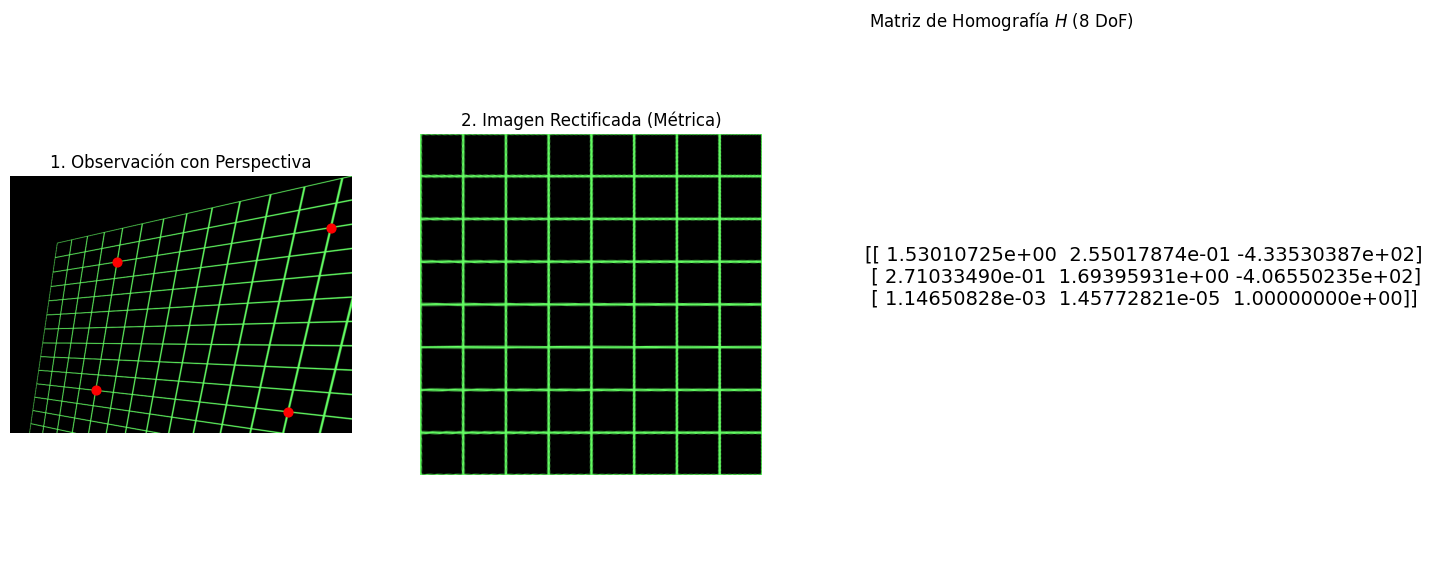

In [ ]:
# EJERCICIO 1: Código Python

def generar_patron_distorsionado(shape=(600, 800), color=(100, 255, 100)):
    """Genera una imagen sintética de una rejilla vista con fuerte perspectiva."""
    img = np.zeros((shape[0], shape[1], 3), dtype=np.uint8)

    # Definir esquinas de un cuadrado ideal en el espacio del objeto
    ancho, alto = 400, 400
    cx, cy = shape[1]//2, shape[0]//2
    puntos_ideales = np.array([
        [cx - ancho//2, cy - alto//2], # Sup Izq
        [cx + ancho//2, cy - alto//2], # Sup Der
        [cx + ancho//2, cy + alto//2], # Inf Der
        [cx - ancho//2, cy + alto//2]  # Inf Izq
    ], dtype=np.float32)

    # Definir una transformación de perspectiva sintética (fuerte)
    puntos_distorsionados = np.array([
        [cx - 150, cy - 100], # Sup Izq (empujado hacia adentro)
        [cx + 350, cy - 180], # Sup Der (estirado)
        [cx + 250, cy + 250], # Inf Der (estirado)
        [cx - ancho//2, cy + alto//2]  # Inf Izq (fijo)
    ], dtype=np.float32)

    # Calcular la Homografía sintética
    H_sintetica, _ = cv2.findHomography(puntos_ideales, puntos_distorsionados)

    # Dibujar rejilla ideal y aplicarle perspectiva
    grid_ideal = np.zeros((1000, 1000, 3), dtype=np.uint8)
    step = 50
    for x in range(0, 1000, step):
        cv2.line(grid_ideal, (x, 0), (x, 1000), color, 2)
        cv2.line(grid_ideal, (0, x), (1000, x), color, 2)

    # Aplicar la homografía a la imagen de la rejilla
    img_perspectiva = cv2.warpPerspective(grid_ideal, H_sintetica, (shape[1], shape[0]))

    return img_perspectiva, puntos_distorsionados

# 1. Generar la "observación"
img_observada, esquinas_leidas = generar_patron_distorsionado()

# 2. CALCULAR LA RECTIFICACIÓN (El algoritmo de análisis)
# Supongamos que sabemos que el objeto es un cuadrado perfecto
ancho_real = 400
esquinas_objetivo = np.array([
    [0, 0],
    [ancho_real, 0],
    [ancho_real, ancho_real],
    [0, ancho_real]
], dtype=np.float32)

# Encontrar H que mapea la observación -> vista métrica ideal
H_rectificar, _ = cv2.findHomography(esquinas_leidas, esquinas_objetivo)

# Aplicar la rectificación
img_rectificada = cv2.warpPerspective(img_observada, H_rectificar, (ancho_real, ancho_real))

# Visualización
plt.figure(figsize=(15, 7))
plt.subplot(1, 3, 1)
plt.title("1. Observación con Perspectiva")
plt.imshow(img_observada)
for p in esquinas_leidas: plt.scatter(p[0], p[1], c='red', s=40)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. Imagen Rectificada (Métrica)")
plt.imshow(img_rectificada)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Matriz de Homografía $H$ (8 DoF)")
plt.text(0.1, 0.5, f"{H_rectificar}", fontsize=14)
plt.axis('off')
plt.show()

---
## Módulo 2: Calibración y Modelado de Lentes (30 min)

La calibración de cámara es el proceso de determinar los parámetros **Intrínsecos** (longitud focal, punto principal, distorsión) y **Extrínsecos** (rotación y traslación en el mundo) de un sistema óptico.

Un modelo físico realista debe incluir la distorsión de la lente, típicamente radial (barril/cojín) debido a la variación de la magnificación con la distancia al eje óptico, y tangencial debido al desalineamiento de los elementos de la lente.

$$\begin{aligned} x' &= x(1 + k_1 r^2 + k_2 r^4 + k_3 r^6) \\ y' &= y(1 + k_1 r^2 + k_2 r^4 + k_3 r^6) \end{aligned}$$

### Ejercicio 2: Modelado y Corrección de Distorsión Radial de Lente
Simularemos una imagen de una rejilla ortogonal perfecta y le aplicaremos matemáticamente una distorsión de "barril" severa. Luego, usaremos algoritmos de visión para estimar los coeficientes $k_n$ y "desdistorsionar" la señal.

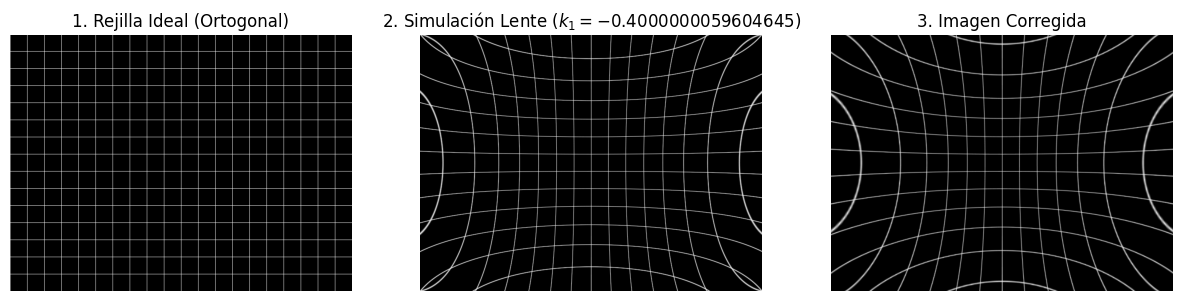

In [ ]:
# EJERCICIO 2: Código Python

def aplicar_distorsion_radial(shape=(600, 800), k1=-0.5):
    """Simula una distorsión de lente radial (barril) sobre una rejilla ideal."""
    h, w = shape
    img = np.zeros((h, w, 3), dtype=np.uint8)

    # Matriz de cámara intrínseca ideal (centro perfecto, focal arbitraria)
    f = 500
    K = np.array([[f, 0, w/2], [0, f, h/2], [0, 0, 1]], dtype=np.float32)
    # Solo distorsión radial k1, el resto cero
    D = np.array([k1, 0, 0, 0], dtype=np.float32)

    # Generar rejilla perfecta
    step = 40
    for x in range(0, w, step):
        cv2.line(img, (x, 0), (x, h), (255, 255, 255), 1)
    for y in range(0, h, step):
        cv2.line(img, (0, y), (w, y), (255, 255, 255), 1)

    # Aplicar distorsión
    # Creamos mapas de mapeo de píxeles
    map_x, map_y = cv2.initUndistortRectifyMap(K, D, None, K, (w, h), 5)
    img_distorsionada = cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR)

    return img, img_distorsionada, K, D

# 1. Simular
rejilla_ideal, img_barril, K_true, D_true = aplicar_distorsion_radial(k1=-0.4)

# 2. Corrección (Undistort) - Asumiendo que conocemos K y D
img_corregida = cv2.undistort(img_barril, K_true, D_true)

# Visualización
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.title("1. Rejilla Ideal (Ortogonal)")
plt.imshow(rejilla_ideal)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"2. Simulación Lente ($k_1={D_true[0]}$)")
plt.imshow(img_barril)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("3. Imagen Corregida")
plt.imshow(img_corregida)
plt.axis('off')
plt.show()

---
## Módulo 3: Geometría Epipolar y Dos Vistas (35 min)

Cuando dos cámaras observan la misma escena 3D desde posiciones distintas, existe una relación geométrica rígida entre sus planos de imagen.

### Conceptos Clave:
1.  **Base (Baseline):** La línea que une los centros ópticos $C_1$ y $C_2$.
2.  **Epipolo ($e$):** El punto de intersección de la base con el plano de la imagen. Es la imagen del centro óptico de la *otra* cámara.
3.  **Línea Epipolar:** Para un punto $\mathbf{x}$ en la Imagen 1, su correspondiente 3D $\mathbf{X}$ debe mentir sobre el rayo óptico $C_1\mathbf{x}$. La proyección de este rayo en la Imagen 2 es la línea epipolar. El punto $\mathbf{x}'$ correspondiente *debe* estar sobre esta línea.

Esta restricción reduce la búsqueda de correspondencias de 2D (toda la imagen) a 1D (una línea). Se formaliza mediante la **Matriz Fundamental ($F$)**:
$$\mathbf{x}'^T F \mathbf{x} = 0$$

### Ejercicio 3: Simulación Geométrica de Restricciones Epipolares
Generaremos una escena 3D de puntos sintéticos y la "proyectaremos" en dos cámaras estéreo. Luego, dibujaremos las líneas epipolares para visualizar cómo un punto en una cámara "constriñe" la posición de su pareja en la otra.

<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_8780/624525103.py:54: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title("Cámara 1: Puntos de Interés $\mathbf{x}$")
/tmp/ipykernel_8780/624525103.py:55: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title("Cámara 2: Líneas Epipolares $l' = F\mathbf{x}$")


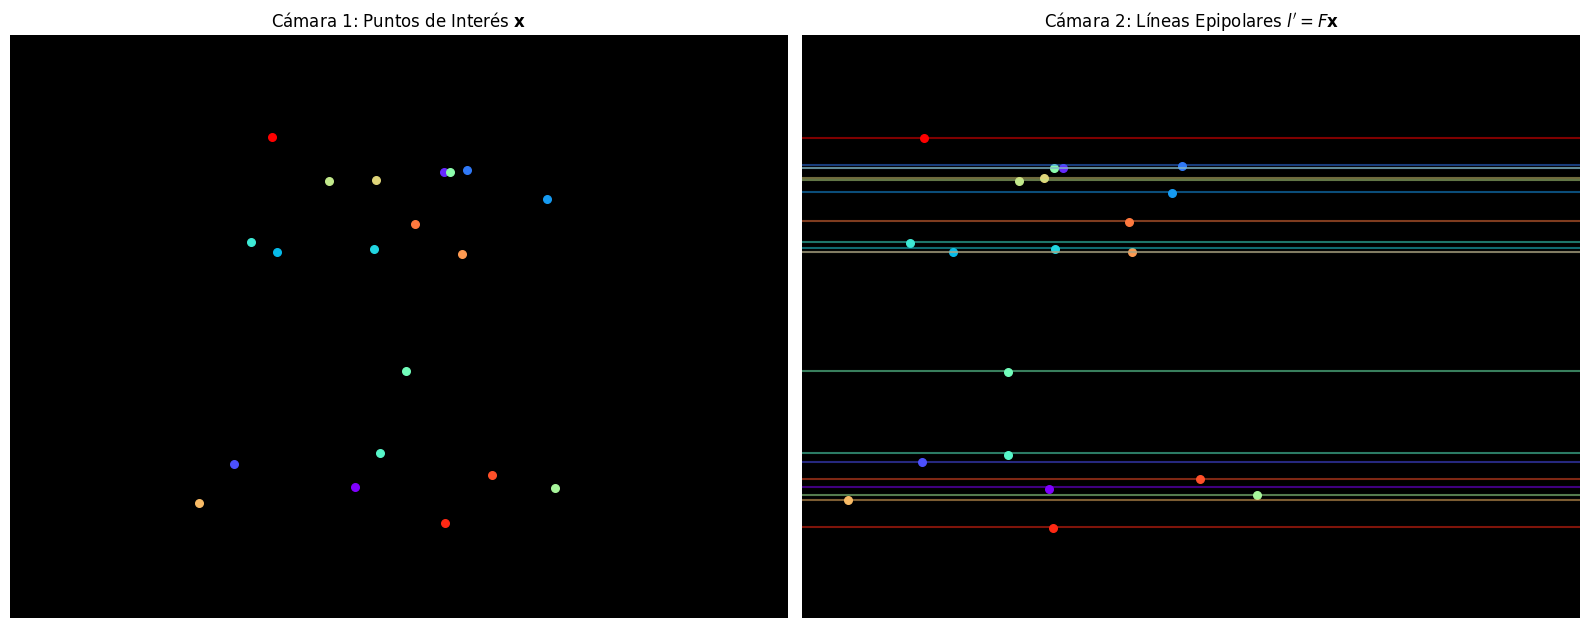

In [ ]:
# EJERCICIO 3: Código Python

def simular_geometria_epipolar():
    # 1. Escena 3D: Puntos aleatorios en un cubo
    np.random.seed(42)
    n_puntos = 20
    puntos_3D = np.random.uniform(-1, 1, (n_puntos, 3))
    puntos_3D[:, 2] += 5 # Empujar el cubo 5 unidades en Z

    # 2. Configuración de Cámaras (Intrínsecas ideales)
    f, w, h = 800, 640, 480
    K = np.array([[f, 0, w/2], [0, f, h/2], [0, 0, 1]], dtype=np.float32)

    # Extrínsecas
    # Cámara 1: En el origen, mirando adelante
    R1 = np.eye(3)
    t1 = np.zeros((3, 1))

    # Cámara 2: Desplazada en X (Base), rotada levemente
    t2 = np.array([[-1.5], [0], [0]]) # Base de 1.5 unidades
    # Rotación de 10 grados en Y
    theta = np.radians(10)
    R2 = np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])

    # Matrices de Proyección P = K [R | t]
    P1 = K @ np.hstack((R1, t1))
    P2 = K @ np.hstack((R2, t2))

    # 3. Proyectar puntos 3D -> 2D
    def proyectar(P, puntos):
        pts_homo = np.hstack((puntos, np.ones((puntos.shape[0], 1))))
        pts_2D_h = (P @ pts_homo.T).T
        return pts_2D_h[:, :2] / pts_2D_h[:, 2:]

    pts1 = proyectar(P1, puntos_3D)
    pts2 = proyectar(P2, puntos_3D)

    # 4. Calcular Matriz Fundamental (F) sintética
    # F = K'^-T * [t]_x * R * K^-1 (Modelo teórico)
    # Simplificación OpenCV para puntos perfectos
    F, _ = cv2.findFundamentalMat(pts1, pts2, cv2.FM_8POINT)

    return pts1, pts2, F, (h, w)

# Ejecutar simulación
pts1, pts2, F, shape = simular_geometria_epipolar()

# Visualización Epipolar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
ax1.set_title("Cámara 1: Puntos de Interés $\mathbf{x}$")
ax2.set_title("Cámara 2: Líneas Epipolares $l' = F\mathbf{x}$")

colors = plt.cm.rainbow(np.linspace(0, 1, len(pts1)))

# Dibujar puntos en Cam 1
for i, pt in enumerate(pts1):
    ax1.scatter(pt[0], pt[1], color=colors[i], s=30)
ax1.imshow(np.zeros(shape), cmap='gray') # Fondo negro simulado
ax1.axis('off')

# Calcular y dibujar líneas epipolares en Cam 2 correspondientes apts1
lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1, 1, 2), 1, F)
lines2 = lines2.reshape(-1, 3)

for i, (line, pt2) in enumerate(zip(lines2, pts2)):
    # Línea es ax + by + c = 0
    x0, y0 = 0, int(-line[2] / line[1])
    x1, y1 = shape[1], int(-(line[2] + line[0]*shape[1]) / line[1])
    ax2.plot([x0, x1], [y0, y1], color=colors[i], alpha=0.5)
    ax2.scatter(pt2[0], pt2[1], color=colors[i], s=30) # Punto real correspondiente

ax2.imshow(np.zeros(shape), cmap='gray')
ax2.axis('off')
plt.tight_layout()
plt.show()

---
## Ejercicio de Cierre y Discusión (10 min)
**Para los Físicos e Ingenieros Ópticos:**
Analiza los resultados del *Ejercicio 3*.
1.  Observa las líneas epipolares en la Cámara 2. ¿Hacia dónde convergen todas las líneas fuera de la imagen? Ese punto matemático es el **Epipolo**.
2.  ¿Qué sucede con la matriz Fundamental $F$ si la segunda cámara *solo* se traslada en el eje Z (movimiento de avance/zoom)? ¿Cómo cambiaría la geometría de las líneas epipolares resultante?